In [1]:
import sys
sys.path.append('..')

# GPU 설정은 common 모듈을 import 하기 전에 해야 한다.
# common/np.py 가 import 시점에 config.GPU 값을 읽기 때문.
from common import config
config.GPU = True

import numpy          # 순수 CPU 연산용 (책 설명 셀에서 사용)
from common.np import *  # GPU면 np -> cupy, 아니면 np -> numpy

------------------------------------------------------------
                       GPU Mode (cupy)
------------------------------------------------------------



In [2]:
W = numpy.arange(21).reshape(7,3)
print(W)
print(W[2])
print(W[5])

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]
 [15 16 17]
 [18 19 20]]
[6 7 8]
[15 16 17]


In [3]:
idx = numpy.array([1, 0, 3, 0])
print(W[idx])

[[ 3  4  5]
 [ 0  1  2]
 [ 9 10 11]
 [ 0  1  2]]


In [4]:
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out

    def backward(self, dout):
        dW, = self.grads
        dW[...] = 0

        for i, word_id in enumerate(self.idx):
            dW[word_id] += dout[i]
        # 혹은
        # np.add.at(dW, self.idx, dout) # 일반적

        return None

In [5]:
class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W)
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None

    def forward(self, h, idx):
        target_W = self.embed.forward(idx)
        out = np.sum(target_W * h, axis=1)

        self.cache = (h, target_W)
        return out

    def backward(self, dout):
        h, target_W = self.cache
        dout = dout.reshape(dout.shape[0], 1)

        dtarget_W = dout * h
        self.embed.backward(dtarget_W)
        dh = dout * target_W
        return dh

In [6]:
# 0에서 9까지의 숫자 중 하나를 무작위로 샘플링
print(numpy.random.choice(10))

# words 에서 하나만 무작위로 샘플링
words = ['you', 'say', 'goodbye', 'I', 'hello', '.']
print(numpy.random.choice(words))

# 5 개만 무작위로 샘플링 (중복 O)
print(numpy.random.choice(words, size=5))

# 5 개만 무작위로 샘플링 (중복 X)
print(numpy.random.choice(words, size=5, replace=False))

# 확률분포에 따라 샘플링
p = [0.5, 0.1, 0.05, 0.2, 0.05, 0.1]
print(numpy.random.choice(words, size=5, p=p))

8
goodbye
['.' 'say' 'goodbye' 'say' 'goodbye']
['you' 'goodbye' 'say' 'hello' '.']
['you' 'you' '.' 'goodbye' 'I']


In [7]:
p = [0.7, 0.29, 0.01]
new_p = numpy.power(p, 0.75)
new_p /= numpy.sum(new_p)
print(new_p)

[0.64196878 0.33150408 0.02652714]


In [8]:
import collections

from common.config import GPU


class UnigramSampler:
    def __init__(self, corpus, power, sample_size):
        self.sample_size = sample_size
        self.vocab_size = None
        self.word_p = None

        counts = collections.Counter()
        for word_id in corpus:
            counts[word_id] += 1

        vocab_size = len(counts)
        self.vocab_size = vocab_size

        # 확률분포는 CPU에서 만든 뒤 한 번에 옮긴다.
        # (GPU 배열에 원소 단위로 대입하면 커널 호출이 vocab_size 번 일어남)
        word_p = numpy.zeros(vocab_size)
        for i in range(vocab_size):
            word_p[i] = counts[i]

        word_p = numpy.power(word_p, power)
        word_p /= numpy.sum(word_p)
        self.word_p = np.asarray(word_p)

    def get_negative_sample(self, target):
        batch_size = target.shape[0]

        if not GPU:
            negative_sample = np.zeros((batch_size, self.sample_size), dtype=np.int32)

            for i in range(batch_size):
                p = self.word_p.copy()
                target_idx = target[i]
                p[target_idx] = 0
                p /= p.sum()
                negative_sample[i, :] = np.random.choice(self.vocab_size, size=self.sample_size, replace=False, p=p)
        else:
            # GPU(cupy）로 계산할 때는 속도를 우선한다.
            # 부정적 예에 타깃이 포함될 수 있다.
            negative_sample = np.random.choice(self.vocab_size, size=(batch_size, self.sample_size),
                                               replace=True, p=self.word_p)

        return negative_sample

In [9]:
corpus = numpy.array([0, 1, 2, 3, 4, 1, 2, 3])
power = 0.75
sample_size = 2

sampler = UnigramSampler(corpus, power, sample_size)
target = numpy.array([1, 3, 0])
negative_sample = sampler.get_negative_sample(target)
print(negative_sample)

[[2 0]
 [4 0]
 [1 3]]


In [10]:
from common.layers import SigmoidWithLoss


class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in range(sample_size + 1)]
        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)

        # 정답(positive sample) 계산
        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=np.int32)
        loss = self.loss_layers[0].forward(score, correct_label)

        # 부정적 예(negative sample) 계산
        negative_label = np.zeros(batch_size, dtype=np.int32)
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[i + 1].forward(h, negative_target)
            loss += self.loss_layers[i + 1].forward(score, negative_label)

        return loss

    def backward(self, dout=1):
        dh = 0

        for l0, l1 in zip(self.loss_layers, self.embed_dot_layers):
            dscore = l0.backward(dout)
            dh += l1.backward(dscore)

        return dh

In [11]:
from common.layers import Embedding

class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size

        # 가중치 초기화
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(V, H).astype('f')

        # 계층 생성
        self.in_layers = []
        for i in range(2 * window_size):
            layer = Embedding(W_in) # Embedding 계층 사용
            self.in_layers.append(layer)
        self.ns_loss = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)

        # 모든 가중치와 기울기를 리스트에 저장.
        layers = self.in_layers + [self.ns_loss]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 인스턴스 변수에 단어의 분산 표현 저장.
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = 0
        for i, layer in enumerate(self.in_layers):
            h += layer.forward(contexts[:, i])
        h *= 1 / len(self.in_layers)

        loss = self.ns_loss.forward(h, target)
        return loss

    def backward(self, dout=1):
        dout = self.ns_loss.backward(dout)
        dout *= 1 / len(self.in_layers)

        for layer in self.in_layers:
            layer.backward(dout)

        return None

| 에폭 1 |  반복 1 / 9295 | 시간 17[s] | 손실 4.16
| 에폭 1 |  반복 21 / 9295 | 시간 17[s] | 손실 4.16
| 에폭 1 |  반복 41 / 9295 | 시간 17[s] | 손실 4.15
| 에폭 1 |  반복 61 / 9295 | 시간 18[s] | 손실 4.12
| 에폭 1 |  반복 81 / 9295 | 시간 18[s] | 손실 4.04
| 에폭 1 |  반복 101 / 9295 | 시간 18[s] | 손실 3.92
| 에폭 1 |  반복 121 / 9295 | 시간 19[s] | 손실 3.78
| 에폭 1 |  반복 141 / 9295 | 시간 19[s] | 손실 3.63
| 에폭 1 |  반복 161 / 9295 | 시간 20[s] | 손실 3.49
| 에폭 1 |  반복 181 / 9295 | 시간 20[s] | 손실 3.35
| 에폭 1 |  반복 201 / 9295 | 시간 20[s] | 손실 3.25
| 에폭 1 |  반복 221 / 9295 | 시간 21[s] | 손실 3.17
| 에폭 1 |  반복 241 / 9295 | 시간 21[s] | 손실 3.09
| 에폭 1 |  반복 261 / 9295 | 시간 22[s] | 손실 3.02
| 에폭 1 |  반복 281 / 9295 | 시간 22[s] | 손실 2.98
| 에폭 1 |  반복 301 / 9295 | 시간 23[s] | 손실 2.91
| 에폭 1 |  반복 321 / 9295 | 시간 23[s] | 손실 2.89
| 에폭 1 |  반복 341 / 9295 | 시간 24[s] | 손실 2.86
| 에폭 1 |  반복 361 / 9295 | 시간 24[s] | 손실 2.82
| 에폭 1 |  반복 381 / 9295 | 시간 24[s] | 손실 2.81
| 에폭 1 |  반복 401 / 9295 | 시간 25[s] | 손실 2.77
| 에폭 1 |  반복 421 / 9295 | 시간 25[s] | 손실 2.76
| 에폭 1 |  반복 441

c:\Users\arang\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\arang\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\arang\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\arang\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


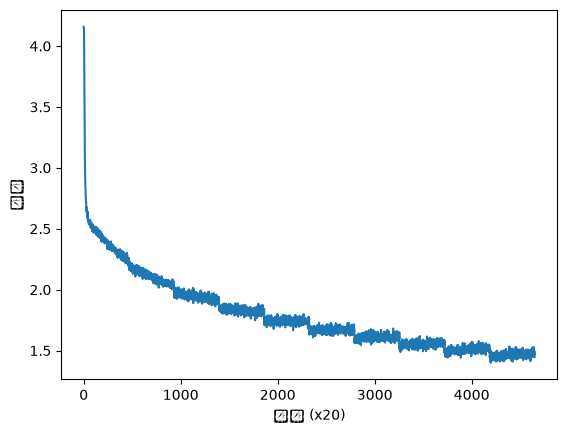

In [12]:
import pickle
from common.trainer import Trainer
from common.optimizer import Adam
from common.util import create_contexts_target, to_cpu, to_gpu
from dataset import ptb

# 하이퍼파라미터 설정
window_size = 5
hidden_size = 100
batch_size = 100
max_epoch = 10

# 데이터 읽기
corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)
if config.GPU:
    contexts, target = to_gpu(contexts), to_gpu(target)

# 모델 등 생성
model = CBOW(vocab_size, hidden_size, window_size, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)

# 학습 시작
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()  # 학습 경과 그래프 그리기

# 나중에 사용할 수 있도록 필요한 데이터 저장
word_vecs = model.word_vecs
if config.GPU:
    word_vecs = to_cpu(word_vecs)
params = {}
params['word_vecs'] = word_vecs.astype(numpy.float16)
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word
pkl_file = 'cbow_params.pkl'
with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)

In [15]:
import common.util as util
from common.util import most_similar
import pickle

pkl_file = 'cbow_params.pkl'

with open(pkl_file, 'rb') as f:
    params = pickle.load(f)
    word_vecs = params['word_vecs']
    word_to_id = params['word_to_id']
    id_to_word = params['id_to_word']

# 평가는 CPU에서 한다.
# - word_vecs 는 pkl 에서 읽은 numpy 배열
# - most_similar 안에서 id_to_word[i] 로 dict 를 조회하는데,
#   cupy 의 argsort 결과는 dict 키로 쓸 수 없다.
# 학습 셀을 다시 돌릴 수 있도록 끝나면 되돌린다. (to_cpu 가 np.asnumpy 를 쓴다)
_np_backup = util.np
util.np = numpy
try:
    querys = ['you', 'year', 'car', 'toyota']
    for query in querys:
        most_similar(query, word_to_id, id_to_word, word_vecs, top=5)
finally:
    util.np = _np_backup


[query] you
 i: 0.72021484375
 we: 0.71533203125
 your: 0.62890625
 they: 0.62109375
 weird: 0.5556640625

[query] year
 month: 0.86279296875
 summer: 0.79296875
 week: 0.791015625
 spring: 0.78369140625
 decade: 0.6513671875

[query] car
 luxury: 0.62841796875
 window: 0.5966796875
 auto: 0.59326171875
 truck: 0.5908203125
 cars: 0.57275390625

[query] toyota
 honda: 0.68115234375
 motor: 0.6220703125
 chevrolet: 0.61572265625
 marathon: 0.60302734375
 coated: 0.59619140625


In [18]:
from common.util import analogy

analogy('king', 'man', 'queen', word_to_id, id_to_word, word_vecs)
analogy('take', 'took', 'go', word_to_id, id_to_word, word_vecs)
analogy('car', 'cars', 'child', word_to_id, id_to_word, word_vecs)
analogy('good', 'better', 'bad', word_to_id, id_to_word, word_vecs)


[analogy] king:man = queen:?
 a.m: 6.04296875
 woman: 4.9296875
 hacker: 4.73828125
 fbi: 4.625
 naczelnik: 4.6171875

[analogy] take:took = go:?
 're: 4.734375
 eurodollars: 4.44921875
 went: 4.40625
 came: 4.21484375
 were: 4.13671875

[analogy] car:cars = child:?
 a.m: 6.2421875
 children: 5.90234375
 rape: 5.34375
 version: 4.859375
 adults: 4.7734375

[analogy] good:better = bad:?
 more: 5.9453125
 rather: 5.8828125
 less: 5.68359375
 greater: 4.9453125
 worse: 4.296875
